In [1]:
import sys
sys.path.append("/mnt/home/asante/ceph/streams_in_dreams")
import EXP4DREAMS
import astropy.units as u

import matplotlib.pyplot as plt
import numpy as np
import gala.potential as gp
import gala.dynamics as gd
from gala.units import galactic
import gala.integrate as gi
import time
import pickle

#=======================================================
# User inputs

# Simulation
box = 34
snap_path = "/mnt/home/dreams/ceph/Sims/CDM/MW_zooms/SB5/"
group_path = "/mnt/home/dreams/ceph/FOF_Subfind/CDM/MW_zooms/SB5/"



# BFE
basis_dict = {# PartType : basis params 
              1: {"Lmax": 6, "nmax": 20, "numr": 2000}}
density_dict = {1: {"bins": 400, 
                    "rangevals": [0, 2.5] # log10 scale
                    }
                }
snapshots =  [61, 67, 73, 81, 90]
dt = 1*u.Myr # for orbit integration

# Output directory
output_dir = "/mnt/home/asante/ceph/parc/"


In [ ]:
#=======================================================
# Create simulation object
MW_sim = EXP4DREAMS.DREAMSMW(box=box,
                             snap_path=snap_path,
                             group_path=group_path)

# Select DM particles at random from different regions of the galaxy
n = 10
shells = [(0,5), (5,20), (20,50), (50,100)]
rng = np.random.default_rng(seed=123)
DM_particles = MW_sim.__load_part_data__(snap=snapshots[0], PartType=1)
DM_ids = []
for r_min, r_max in shells:
    # Select particles within that shell at random
    idx = (DM_particles["r"]>r_min) & (DM_particles["r"]<r_max)
    DM_ids_shell = DM_particles["iord"][idx] 
    
    DM_ids.append(rng.choice(DM_ids_shell, size=n, replace=False))

DM_ids = np.hstack(DM_ids)
sim_tracks = MW_sim.track_particles(DM_ids, 1, snapshots=snapshots)


In [3]:
# Use EXP approximation to replicate the particle orbits
# Create EXPpotential
EXP_gen = EXP4DREAMS.EXPBFE_builder(sim=MW_sim,
                                    basis_params_dict=basis_dict,
                                    density_dict=density_dict,
                                    snapshots = snapshots,
                                    output_dir=output_dir)


pot, exp_units = EXP_gen.build_gala_potential()

Building basis for the expansion...
! Scaling:  R= 1.3286940743547595   M= 1.0
1.0 0.9687090541316983 0.9687090541316983 0.9687090541316983
{'id': 'sphereSL', 'parameters': {'numr': 2000, 'rmin': 0.004232042283097917, 'rmax': 1, 'Lmax': 6, 'nmax': 20, 'rmapping': 0.067, 'modelname': '/mnt/home/asante/ceph/parc/basis_empirical_PartType1_box_0034.txt', 'cachename': '/mnt/home/asante/ceph/parc/basis_empirical_PartType1_box_0034.cache.run0'}}
---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/parc/basis_empirical_PartType1_box_0034.cache.run0>
---- Spherical::orthoTest: worst=0.000357303
Calculating the coefficients at snapshots: [61, 67, 73, 81, 90]


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/parc/basis_empirical_PartType1_box_0034.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/parc/basis_empirical_PartType1_box_0034.cache.run0 (File accessibility) Unable to open file>


---- SLGridSph::ReadH5Cache: successfully read basis cache </mnt/home/asante/ceph/parc/basis_empirical_PartType1_box_0034.cache.run0>
---- Spherical::orthoTest: worst=0.000357303


In [ ]:
bfe_tracks = {}

for pid in sim_tracks.keys():
    print(f"Integrating particle ID {pid}...")
    start=time.time()
    ics = gd.PhaseSpacePosition(pos=sim_tracks[pid]["xyz"][:,0], 
                                vel=sim_tracks[pid]["v_xyz"][:,0])
    
    orbit = pot.integrate_orbit(ics, 
                                t1=EXP_gen.coefs[1].Times()[0]*u.Gyr, 
                                t2=EXP_gen.coefs[1].Times()[-1]*u.Gyr, 
                                dt=dt, 
                                Integrator=gi.DOPRI853Integrator,
                                Integrator_kwargs={"atol":1e-4})
    print(f"Done in {time.time()-start} seconds.")
    
    # Exclude 1st and last snapshots because of BFE cannot be evaluated there
    idx = np.arange(len(orbit.t))[1:-1]
    # Position of the particle in the orbit
    xyz = orbit.xyz.to(u.kpc)[:,idx] 
    # Velocity of the particle in the orbit
    v_xyz = orbit.v_xyz.to(u.km/u.s)[:,idx]
    # Time steps at which the orbit is evaluated
    times = orbit.t.to(u.Gyr)[idx]
    # Compute the energy at each time step
    V = pot.energy(xyz, t=times).to(u.km**2 / u.s**2) 
    K = 0.5*np.sum(v_xyz**2, axis=0)
    E = K + V
    # Compute apocenter, pericenter, and eccentricity of the orbit
    apo = orbit.apocenter().to(u.kpc)
    peri = orbit.pericenter().to(u.kpc)
    ecc = orbit.eccentricity()
    
    
    # Save outputs
    bfe_tracks[pid] = {"xyz": xyz,
                       "v_xyz": v_xyz,
                       "E": E,
                       "times": times,
                       "apo": apo,
                       "peri": peri, 
                       "e": ecc
                       }
    
    

pickle.dump(bfe_tracks, open(f"{output_dir}bfe_tracks.pkl", "wb"))
pickle.dump(sim_tracks, open(f"{output_dir}sim_tracks.pkl", "wb"))

Integrating particle ID 2148863...
Done in 35.798774003982544 seconds.
Integrating particle ID 1776929...
Done in 36.73235011100769 seconds.


In [3]:
bfe_tracks = pickle.load(open(f"{output_dir}bfe_tracks.pkl","rb"))
sim_tracks = pickle.load(open(f"{output_dir}sim_tracks.pkl","rb"))

In [6]:
times = bfe_tracks[list(bfe_tracks.keys())[0]]["times"]

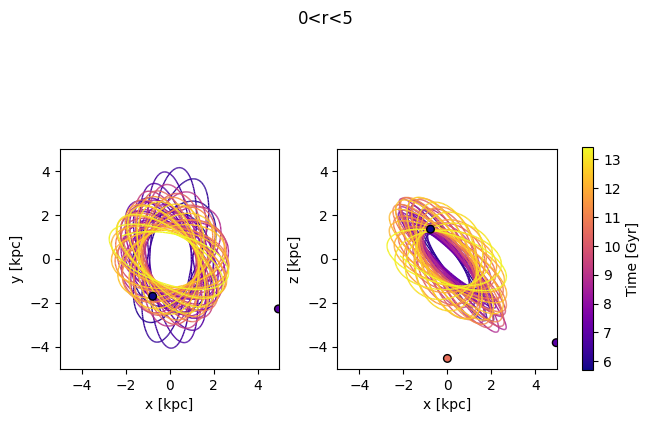

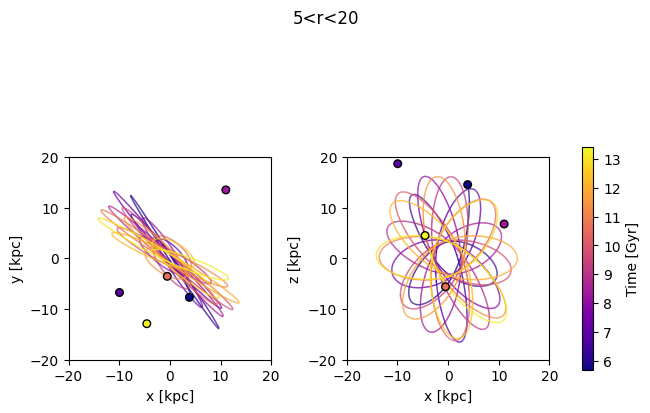

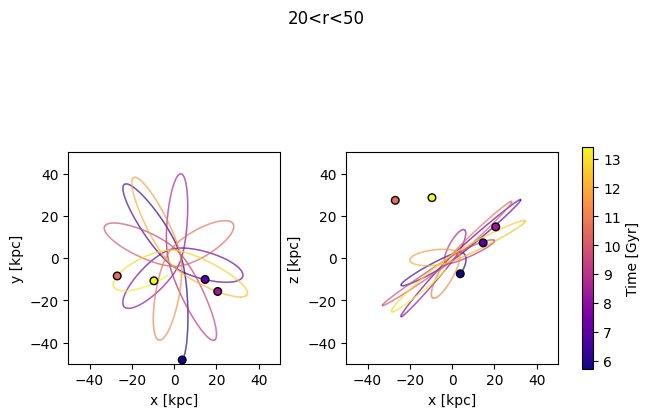

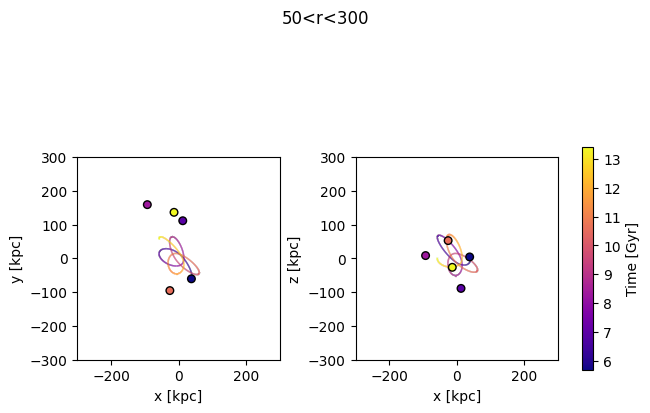

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

cmap = "plasma"

def plot_colored_line(ax, x, y, c, cmap='viridis', linewidth=2, **kwargs):
    """
    Plots a line with a color gradient based on a third variable 'c'.
    
    Parameters
    ----------
    ax : Matplotlib Axes
        The axes to plot on.
    x, y : array-like
        The x and y coordinates of the data points.
    c : array-like
        The color values (e.g., time) that determine the color of each segment.
    cmap : str, optional
        The colormap to use (default is 'viridis').
    linewidth : int, optional
        The width of the line (default is 2).
    """
    # Create segments by pairing up consecutive points
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create a continuous norm to map the 'c' values to colors
    norm = Normalize(c.min(), c.max())
    
    # Create the LineCollection
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth, **kwargs)
    
    # Set the color array
    # We use the 'c' values for the first point of each segment
    lc.set_array(c[:-1]) 
    
    # Add the collection to the axes and get the minimum/maximum limits
    ax.add_collection(lc)
    ax.autoscale_view() # Adjust the plot limits to encompass the new line
    
    return lc # Return the LineCollection object to use with a Colorbar

def plot_orbit_reconstruction(pid,
                              sim_tracks,
                              bfe_tracks):
    
    # Extract data, converting to numpy array if it has a '.value' attribute
    times = bfe_tracks[pid]["times"].value
    x_bfe = bfe_tracks[pid]["xyz"][0]
    y_bfe = bfe_tracks[pid]["xyz"][1]
    z_bfe = bfe_tracks[pid]["xyz"][2]
    
    
    sim_times = EXP_gen.coefs[1].Times()
    
    # Plot the simulation positions (unchanged)
    axs[0].scatter(sim_tracks[pid]["xyz"][0], 
                   sim_tracks[pid]["xyz"][1].value, 
                   c=sim_times, 
                   norm=Normalize(times.min(), times.max()),
                   edgecolors="k",
                   cmap=cmap,
                   s=30, label='Simulation', zorder=100)
    axs[1].scatter(sim_tracks[pid]["xyz"][0], 
                   sim_tracks[pid]["xyz"][2].value, 
                   c=sim_times, 
                   norm=Normalize(times.min(), times.max()),
                   edgecolors="k",
                   cmap=cmap,
                   s=30, label='Simulation', zorder=100)
    
    # Plot the orbit reconstruction using the multicolored line function
    lc0 = plot_colored_line(axs[0], x_bfe, y_bfe, times, cmap=cmap, linewidth=1)
    lc1 = plot_colored_line(axs[1], x_bfe, z_bfe, times, cmap=cmap, linewidth=1)
    
    # Add colorbar for the time dimension
    fig.colorbar(lc0, ax=axs, label='Time [Gyr]', shrink=0.5) 
    
    return
    

all_ids = list(sim_tracks.keys())

for it in range(len(shells)):
    
    ids_plot = all_ids[n*it:n*(it+1)]

    fig, axs = plt.subplots(1,2, layout="constrained")
    axs[0].set_xlabel("x [kpc]")
    axs[1].set_xlabel("x [kpc]")
    axs[0].set_ylabel("y [kpc]")
    axs[1].set_ylabel("z [kpc]")
    
    pid = ids_plot[0]
    
    plot_orbit_reconstruction(pid=pid, sim_tracks=sim_tracks, bfe_tracks=bfe_tracks)
        
    rmin=shells[it][0]
    rmax=shells[it][1]
    for ax in axs:
        ax.set_xlim([-rmax,rmax])
        ax.set_ylim([-rmax,rmax])
        ax.set_aspect(1)
    fig.suptitle(f"{rmin:d}<r<{rmax:d}")

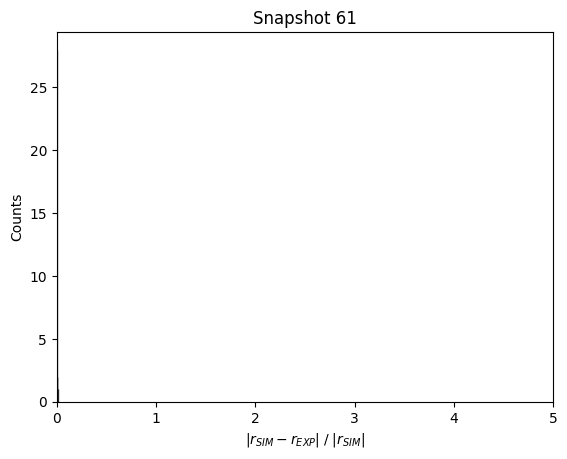

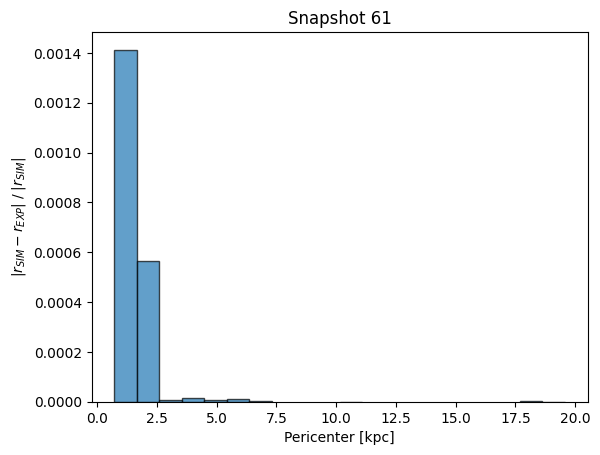

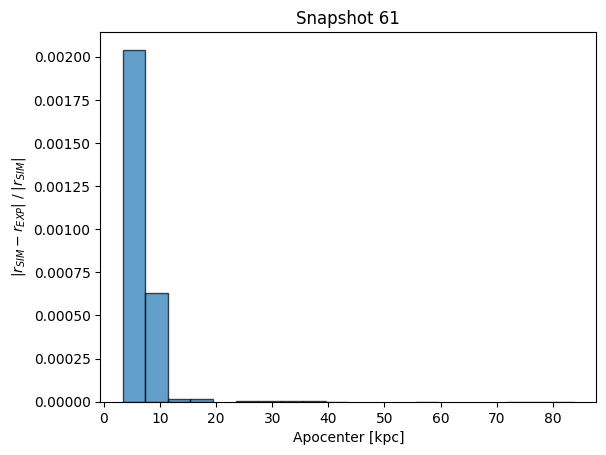

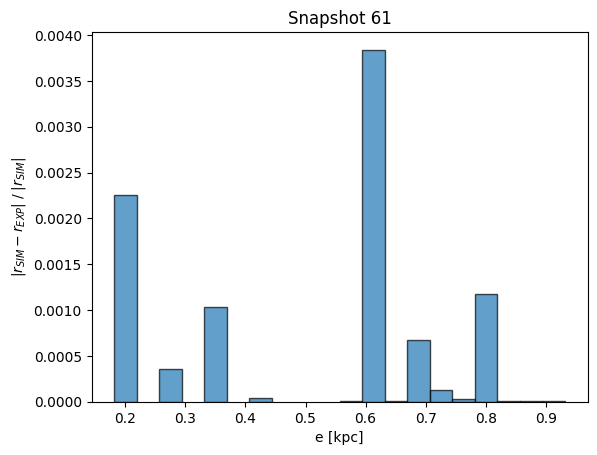

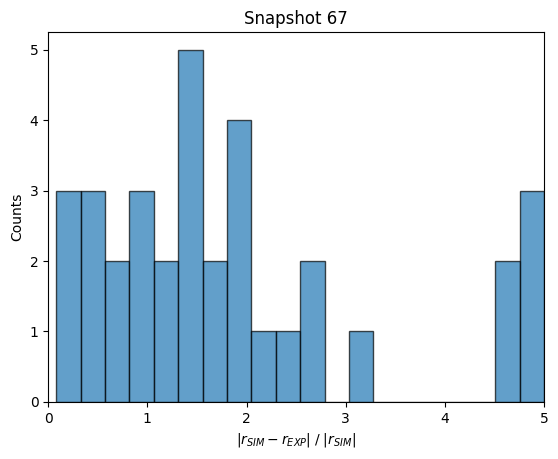

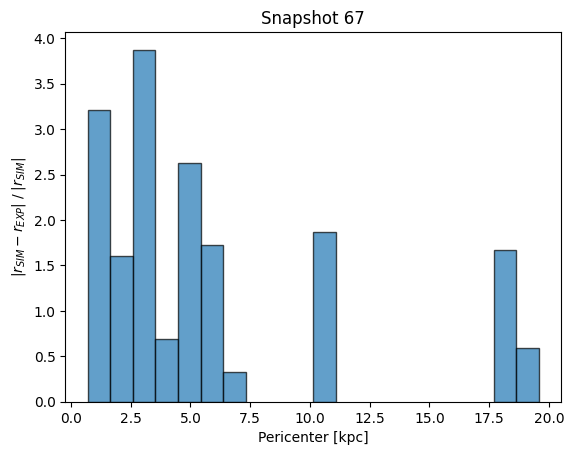

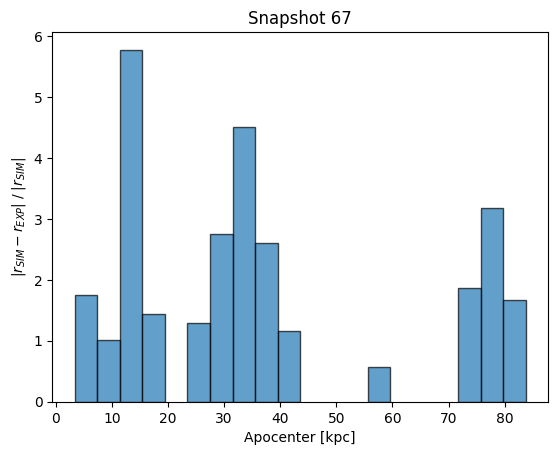

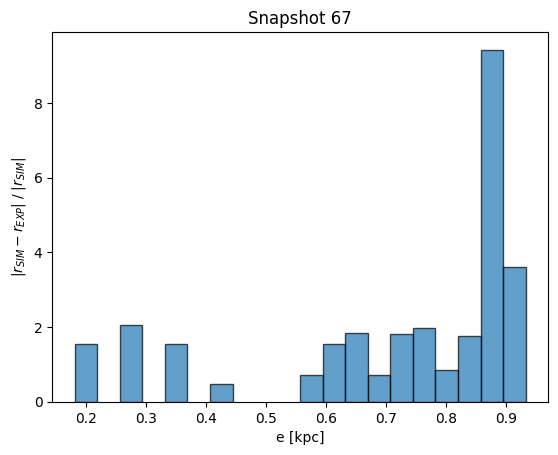

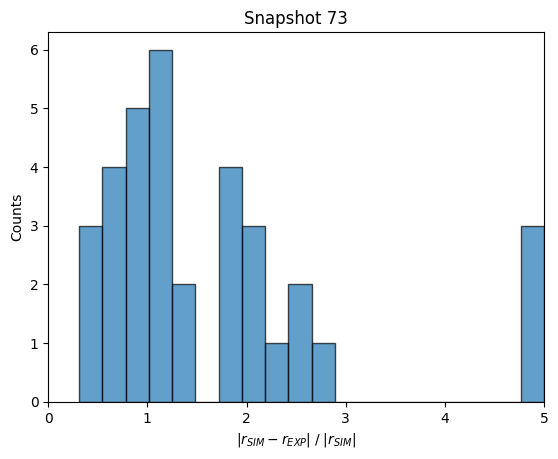

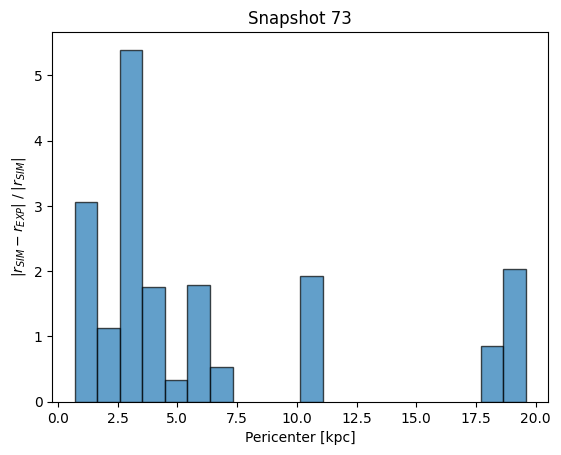

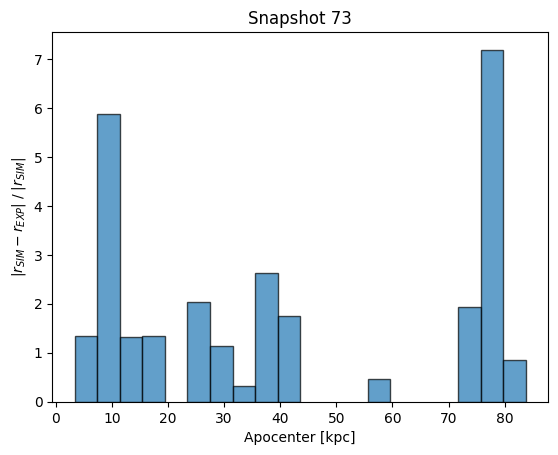

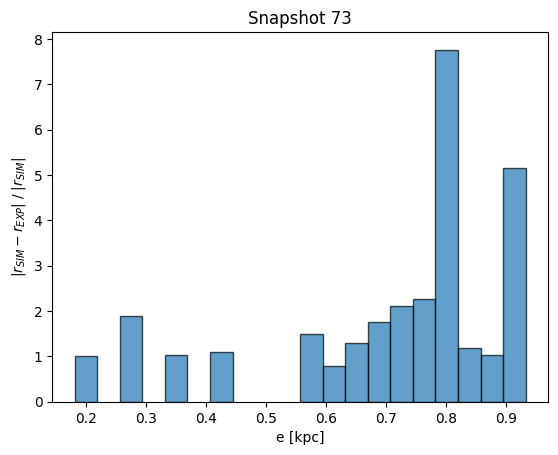

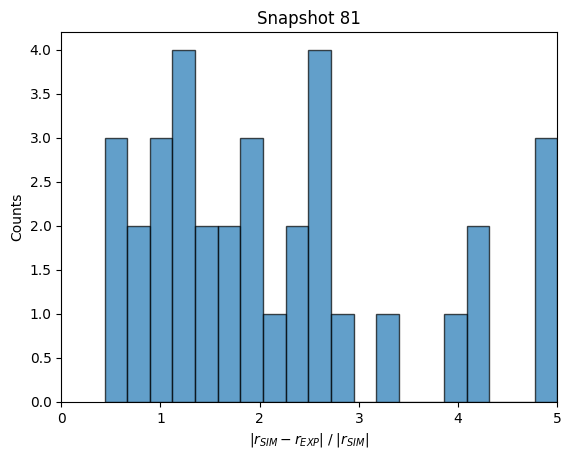

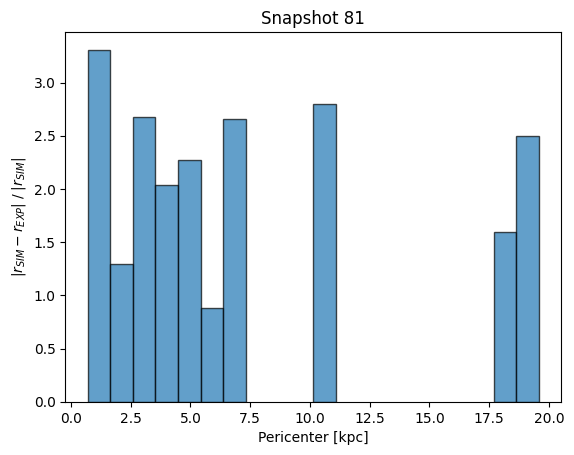

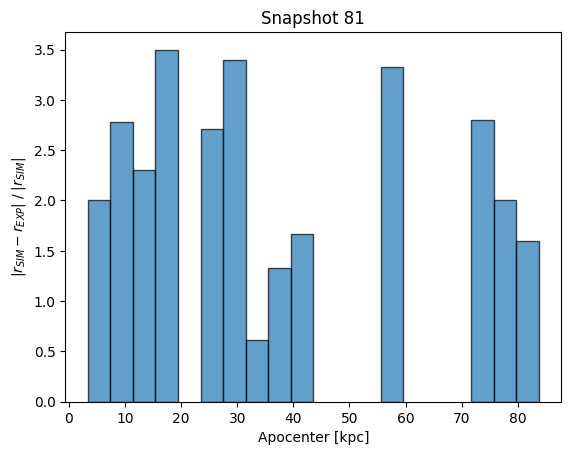

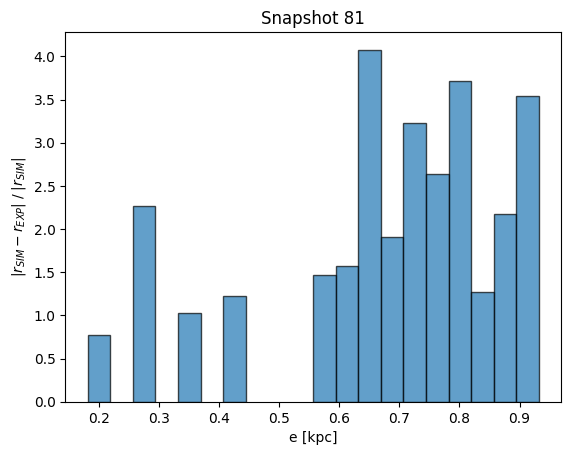

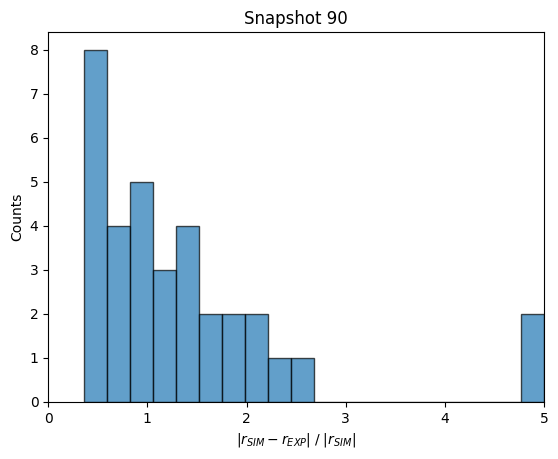

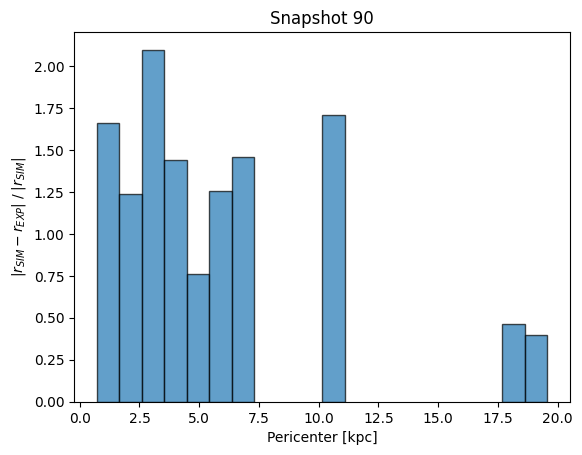

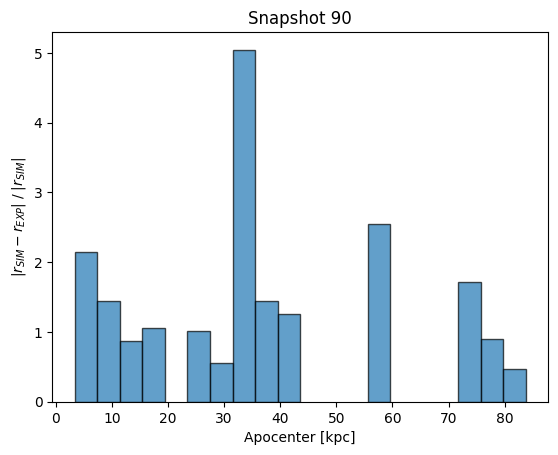

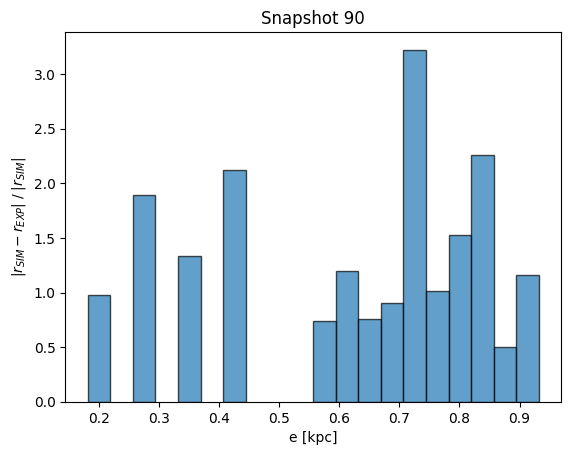

In [71]:
from scipy.stats import binned_statistic


sim_times = EXP_gen.coefs[1].Times()
# Calculate the deviation between the predicted position of the particles and the one from the simulation
for it in range(0,len(snapshots)):
    
    diff_list = []
    apo_list = [bfe_tracks[pid]["apo"].value for pid in sim_tracks.keys()]
    peri_list = [bfe_tracks[pid]["peri"].value for pid in sim_tracks.keys()]
    e_list = [bfe_tracks[pid]["e"].value for pid in sim_tracks.keys()]

    for pid in sim_tracks.keys():
        times = bfe_tracks[pid]["times"].value
        
        
        # Get the time frame that corresponds to the simulation output
        idx_snap = np.argmin((times-sim_times[it])**2)
        
        # Get final position of the particle
        sim_final = sim_tracks[pid]["xyz"][:,it]
        bfe_final = bfe_tracks[pid]["xyz"][:, idx_snap]
        diff = np.sum((sim_final - bfe_final)**2) / np.sum(sim_final**2)
        diff_list.append(diff.value)


        
    fig,ax = plt.subplots()
    ax.set_title(f"Snapshot {snapshots[it]}")
    ax.hist(np.clip(diff_list,a_min=0,a_max=5), bins=20, 
            edgecolor='black', alpha=0.7)
    ax.set_xlim([0,5])
    ax.set_ylabel("Counts")
    ax.set_xlabel("$|r_{SIM}-r_{EXP}|  \; / \; |r_{SIM}|$")
    
    for label, prop_list in zip(["Pericenter", "Apocenter", "e"], [peri_list, apo_list, e_list]):
        counts, bins, _ = binned_statistic(prop_list, diff_list, bins=20)
        bins_centers = 0.5*(bins[1:]+bins[:-1])
        bin_width=bins[1]-bins[0]
        fig,ax = plt.subplots()
        ax.bar(bins_centers, height=counts, width=bin_width,
               align='center', edgecolor='black', alpha=0.7)
        ax.set_title(f"Snapshot {snapshots[it]}")
        ax.set_xlabel(f"{label} [kpc]")
        ax.set_ylabel("$|r_{SIM}-r_{EXP}|  \; / \; |r_{SIM}|$")

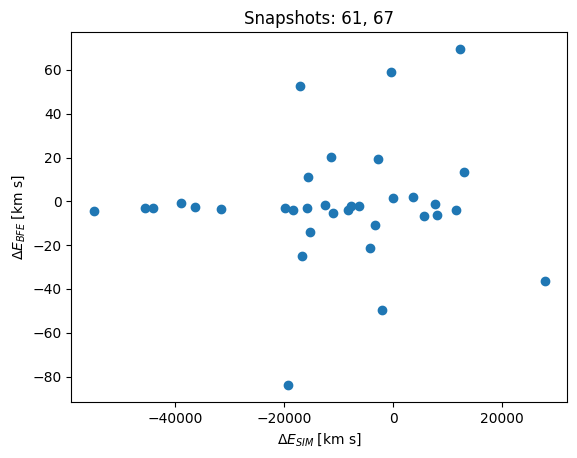

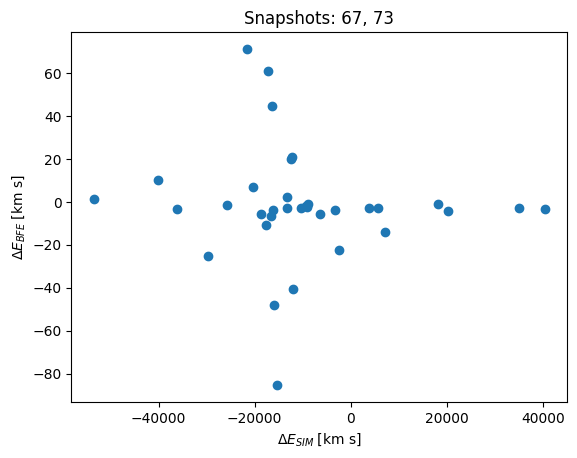

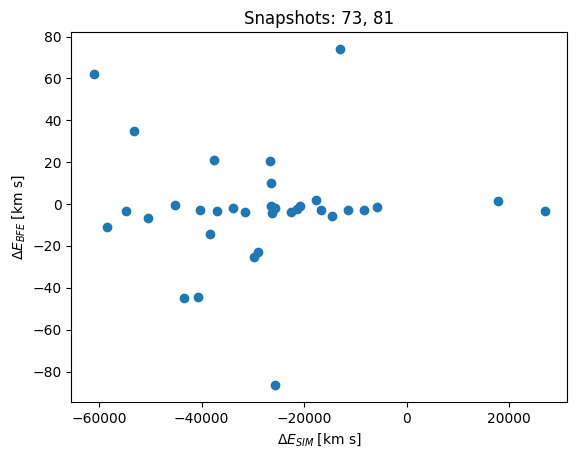

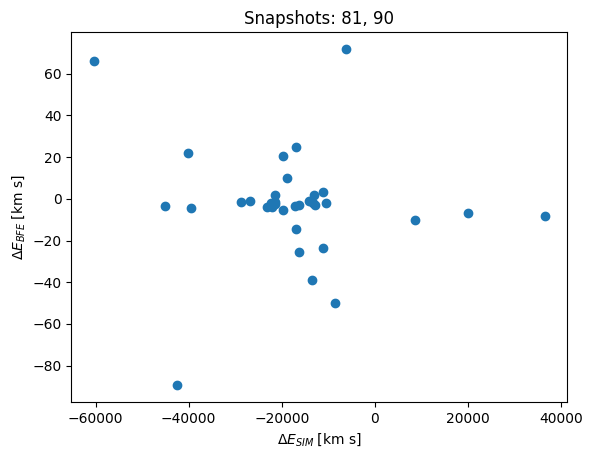

In [68]:


for it in range(len(snapshots)-1):
    
    fig, ax = plt.subplots()
        
    delta_E_sim = [sim_tracks[pid]["E"][it+1] - sim_tracks[pid]["E"][it] for pid in sim_tracks.keys()]
    delta_E_bfe = [bfe_tracks[pid]["E"][it+1].value - bfe_tracks[pid]["E"][it].value for pid in sim_tracks.keys()]
    
    ax.set_xlabel("$\\Delta E_{SIM} \; [\\rm{km} \ \\rm{s}]$")
    ax.set_ylabel("$\\Delta E_{BFE} \; [\\rm{km} \ \\rm{s}]$")
    
    ax.scatter(delta_E_sim, delta_E_bfe)
    
    ax.set_title(f"Snapshots: {snapshots[it]}, {snapshots[it+1]}")

In [ ]:
bfe_tracks = pickle.load(open(f"{output_dir}bfe_tracks_l40n20.pkl","rb"))
sim_tracks = pickle.load(open(f"{output_dir}sim_tracks_l40n20.pkl","rb"))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

cmap = "plasma"

def plot_colored_line(ax, x, y, c, cmap='viridis', linewidth=2, **kwargs):
    """
    Plots a line with a color gradient based on a third variable 'c'.
    
    Parameters
    ----------
    ax : Matplotlib Axes
        The axes to plot on.
    x, y : array-like
        The x and y coordinates of the data points.
    c : array-like
        The color values (e.g., time) that determine the color of each segment.
    cmap : str, optional
        The colormap to use (default is 'viridis').
    linewidth : int, optional
        The width of the line (default is 2).
    """
    # Create segments by pairing up consecutive points
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Create a continuous norm to map the 'c' values to colors
    norm = Normalize(c.min(), c.max())
    
    # Create the LineCollection
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth, **kwargs)
    
    # Set the color array
    # We use the 'c' values for the first point of each segment
    lc.set_array(c[:-1]) 
    
    # Add the collection to the axes and get the minimum/maximum limits
    ax.add_collection(lc)
    ax.autoscale_view() # Adjust the plot limits to encompass the new line
    
    return lc # Return the LineCollection object to use with a Colorbar

def plot_orbit_reconstruction(pid,
                              sim_tracks,
                              bfe_tracks):
    
    # Extract data, converting to numpy array if it has a '.value' attribute
    times = bfe_tracks[pid]["times"].value
    x_bfe = bfe_tracks[pid]["xyz"][0]
    y_bfe = bfe_tracks[pid]["xyz"][1]
    z_bfe = bfe_tracks[pid]["xyz"][2]
    
    
    sim_times = EXP_gen.coefs[1].Times()
    
    # Plot the simulation positions (unchanged)
    axs[0].scatter(sim_tracks[pid]["xyz"][0], 
                   sim_tracks[pid]["xyz"][1].value, 
                   c=sim_times, 
                   norm=Normalize(times.min(), times.max()),
                   edgecolors="k",
                   cmap=cmap,
                   s=30, label='Simulation', zorder=100)
    axs[1].scatter(sim_tracks[pid]["xyz"][0], 
                   sim_tracks[pid]["xyz"][2].value, 
                   c=sim_times, 
                   norm=Normalize(times.min(), times.max()),
                   edgecolors="k",
                   cmap=cmap,
                   s=30, label='Simulation', zorder=100)
    
    # Plot the orbit reconstruction using the multicolored line function
    lc0 = plot_colored_line(axs[0], x_bfe, y_bfe, times, cmap=cmap, linewidth=1)
    lc1 = plot_colored_line(axs[1], x_bfe, z_bfe, times, cmap=cmap, linewidth=1)
    
    # Add colorbar for the time dimension
    fig.colorbar(lc0, ax=axs, label='Time [Gyr]', shrink=0.5) 
    
    return
    

all_ids = list(sim_tracks.keys())

for it in range(len(shells)):
    
    ids_plot = all_ids[n*it:n*(it+1)]

    fig, axs = plt.subplots(1,2, layout="constrained")
    axs[0].set_xlabel("x [kpc]")
    axs[1].set_xlabel("x [kpc]")
    axs[0].set_ylabel("y [kpc]")
    axs[1].set_ylabel("z [kpc]")
    
    pid = ids_plot[0]
    
    plot_orbit_reconstruction(pid=pid, sim_tracks=sim_tracks, bfe_tracks=bfe_tracks)
        
    rmin=shells[it][0]
    rmax=shells[it][1]
    for ax in axs:
        ax.set_xlim([-rmax,rmax])
        ax.set_ylim([-rmax,rmax])
        ax.set_aspect(1)
    fig.suptitle(f"{rmin:d}<r<{rmax:d}")
    
    
#####

from scipy.stats import binned_statistic


sim_times = EXP_gen.coefs[1].Times()
# Calculate the deviation between the predicted position of the particles and the one from the simulation
for it in range(0,len(snapshots)):
    
    diff_list = []
    apo_list = [bfe_tracks[pid]["apo"].value for pid in sim_tracks.keys()]
    peri_list = [bfe_tracks[pid]["peri"].value for pid in sim_tracks.keys()]
    e_list = [bfe_tracks[pid]["e"].value for pid in sim_tracks.keys()]

    for pid in sim_tracks.keys():
        times = bfe_tracks[pid]["times"].value
        
        
        # Get the time frame that corresponds to the simulation output
        idx_snap = np.argmin((times-sim_times[it])**2)
        
        # Get final position of the particle
        sim_final = sim_tracks[pid]["xyz"][:,it]
        bfe_final = bfe_tracks[pid]["xyz"][:, idx_snap]
        diff = np.sum((sim_final - bfe_final)**2) / np.sum(sim_final**2)
        diff_list.append(diff.value)


        
    fig,ax = plt.subplots()
    ax.set_title(f"Snapshot {snapshots[it]}")
    ax.hist(np.clip(diff_list,a_min=0,a_max=5), bins=20, 
            edgecolor='black', alpha=0.7)
    ax.set_xlim([0,5])
    ax.set_ylabel("Counts")
    ax.set_xlabel("$|r_{SIM}-r_{EXP}|  \; / \; |r_{SIM}|$")
    
    for label, prop_list in zip(["Pericenter", "Apocenter", "e"], [peri_list, apo_list, e_list]):
        counts, bins, _ = binned_statistic(prop_list, diff_list, bins=20)
        bins_centers = 0.5*(bins[1:]+bins[:-1])
        bin_width=bins[1]-bins[0]
        fig,ax = plt.subplots()
        ax.bar(bins_centers, height=counts, width=bin_width,
               align='center', edgecolor='black', alpha=0.7)
        ax.set_title(f"Snapshot {snapshots[it]}")
        ax.set_xlabel(f"{label} [kpc]")
        ax.set_ylabel("$|r_{SIM}-r_{EXP}|  \; / \; |r_{SIM}|$")

In [6]:
dens = EXP_gen.volume_render(EXP_gen.basis[1],
                        EXP_gen.coefs[1],
                        field="dens", #potl
                        time=EXP_gen.coefs[1].Times()[-1],
                        grid_lim=1,
                        n_points=100)

In [7]:
dens

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

In [8]:
dir(dens)

['__annotations__',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__init__',
 '__init_subclass__',
 '__isub__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_active_widgets',
 '_add_notifiers',
 '_all_trait_default_generators',
 '_backend_version',
 '_call_widget_constructed',
 '_camera_animation_metadata',
 '_comm_changed',
 '_compare',
 '_control_comm',
 '_cross_validation_lock',
 '_default_keys',
 '_descriptors',
 '_dom_classes',
 '_gen_repr_from_keys',
 '_get_embed_state',
 '_get_trait_default_generator',
 '_handle_control_comm_msg',
 '_handle_custom_msg',
 '_handle_msg',
 '_holding_sync',
 '_instance_inits',
 '_is_numpy',
 '_lock_property',
 '_log_de

In [ ]:
# Create a spherically symmetric distribution


''